# UNSW-NB15 — Network Traffic Volume Prediction
## Regression Track — Preprocessing & EDA (Review 1)

**Course:** 23CSE301 Machine Learning — Capstone Project
**Track:** Regression (this notebook covers Rubric **Section A: Dataset & EDA** and **Section B: Preprocessing & Feature Engineering** for the Regression track — the shared prerequisite steps before the 10-algorithm modelling stage in Section C)
**Dataset:** UNSW-NB15 Intrusion Detection Dataset (`UNSW_NB15_training-set.csv`, `UNSW_NB15_testing-set.csv`)

### Why / how this dataset is used for Regression
UNSW-NB15 was originally built for **intrusion detection (classification)** — its only provided labels, `label` and `attack_cat`, are categorical, not continuous. To use the same dataset for the **Regression track**, we engineer a continuous prediction target out of the traffic-flow measurements themselves:

> **Regression target: `dbytes`** — the number of bytes transferred from destination to source (i.e. the size of the "response" side of a network flow). The task becomes: *given a flow's protocol, timing, and connection-history features, predict how many bytes its response will carry* — a realistic traffic-engineering / capacity-planning problem.

**Leakage check performed before choosing features (this matters — several UNSW-NB15 columns are exact algebraic transforms of byte/packet counts):**

| Column | Relationship to `dbytes` | Decision |
|---|---|---|
| `dmean` | ≈ `dbytes / dpkts` (empirically corr = 0.99999 with that formula) | **Dropped** — exact leakage |
| `dload` | ≈ `dbytes × 8 / dur` (functionally exact once `dur` is a feature) | **Dropped** — exact leakage |
| `sload`, `smean` | Functions of `sbytes` / `spkts`, not `dbytes` | Kept |
| `rate` | Mixes both directions' packet counts over `dur`; not an exact reconstruction | Kept |
| `response_body_len` | A real, distinct measurement, only moderately correlated (0.38 overall) | Kept, flagged |
| `dpkts` | Naturally correlated (0.98) but not a deterministic formula — same relationship as "square footage vs. bedroom count" in a housing-price regression | Kept |
| `attack_cat`, `label` | The Classification-track targets. Not algebraically related to `dbytes`, but deliberately **excluded** from regression features to keep the two tracks' problems cleanly separated (they are not required for this traffic-volume task) | **Dropped** |

`dbytes` itself is extremely right-skewed (as seen in the classification-track EDA), so we will use a **log1p transform of the target** for training/evaluation and report metrics on both the log and original scale.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)


## Section A — Dataset & EDA

### A1. Dataset Loading & Audit


In [2]:
train_df = pd.read_csv("data/raw/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("data/raw/UNSW_NB15_testing-set.csv")

print("Training set shape:", train_df.shape)
print("Testing  set shape:", test_df.shape)
print()
print("Columns ({} total):".format(train_df.shape[1]))
print(list(train_df.columns))


Training set shape: (82332, 45)
Testing  set shape: (175341, 45)

Columns (45 total):
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [3]:
train_df.dtypes.to_frame(name="dtype").T


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
dtype,int64,float64,str,str,str,int64,int64,int64,int64,float64,int64,int64,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str,int64


In [4]:
# Standard missing-value audit
missing_counts = train_df.isnull().sum()
print("Columns with NaN/null values:")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "None found.")

# Domain-specific missing marker: '-' in `service`
print()
print(f"Rows with service == '-' -> train: {(train_df['service']=='-').sum()}, "
      f"test: {(test_df['service']=='-').sum()}")


Columns with NaN/null values:
None found.

Rows with service == '-' -> train: 47153, test: 94168


In [5]:
# Target ('dbytes') audit
print("dbytes — descriptive statistics (training set):")
print(train_df["dbytes"].describe())
print()
print("Skewness of dbytes:", train_df["dbytes"].skew())
print("Skewness of log1p(dbytes):", np.log1p(train_df["dbytes"]).skew())
print()
print("Rows where dbytes == 0:", (train_df["dbytes"] == 0).sum(),
      f"({(train_df['dbytes']==0).mean()*100:.1f}% of training rows)")


dbytes — descriptive statistics (training set):
count    8.233200e+04
mean     1.323379e+04
std      1.514715e+05
min      0.000000e+00
25%      0.000000e+00
50%      1.780000e+02
75%      9.560000e+02
max      1.465753e+07
Name: dbytes, dtype: float64

Skewness of dbytes: 52.550386921780415


Skewness of log1p(dbytes): 0.2489424492101253

Rows where dbytes == 0: 36006 (43.7% of training rows)


**Observation (A1):** The training set has **82,332 rows / 45 columns**; no standard NaN values exist, but `service` uses the `'-'` placeholder for ~57% of rows (same finding as the classification-track audit; handled the same way in Section B). The chosen regression target `dbytes` is **extremely right-skewed** (raw skewness in the hundreds) with a large spike at zero (many flows never sent any response bytes, e.g. one-way scans). Taking `log1p(dbytes)` sharply reduces the skew, which is why we adopt it as the actual training target rather than raw `dbytes`.


### A2. EDA Visualisations


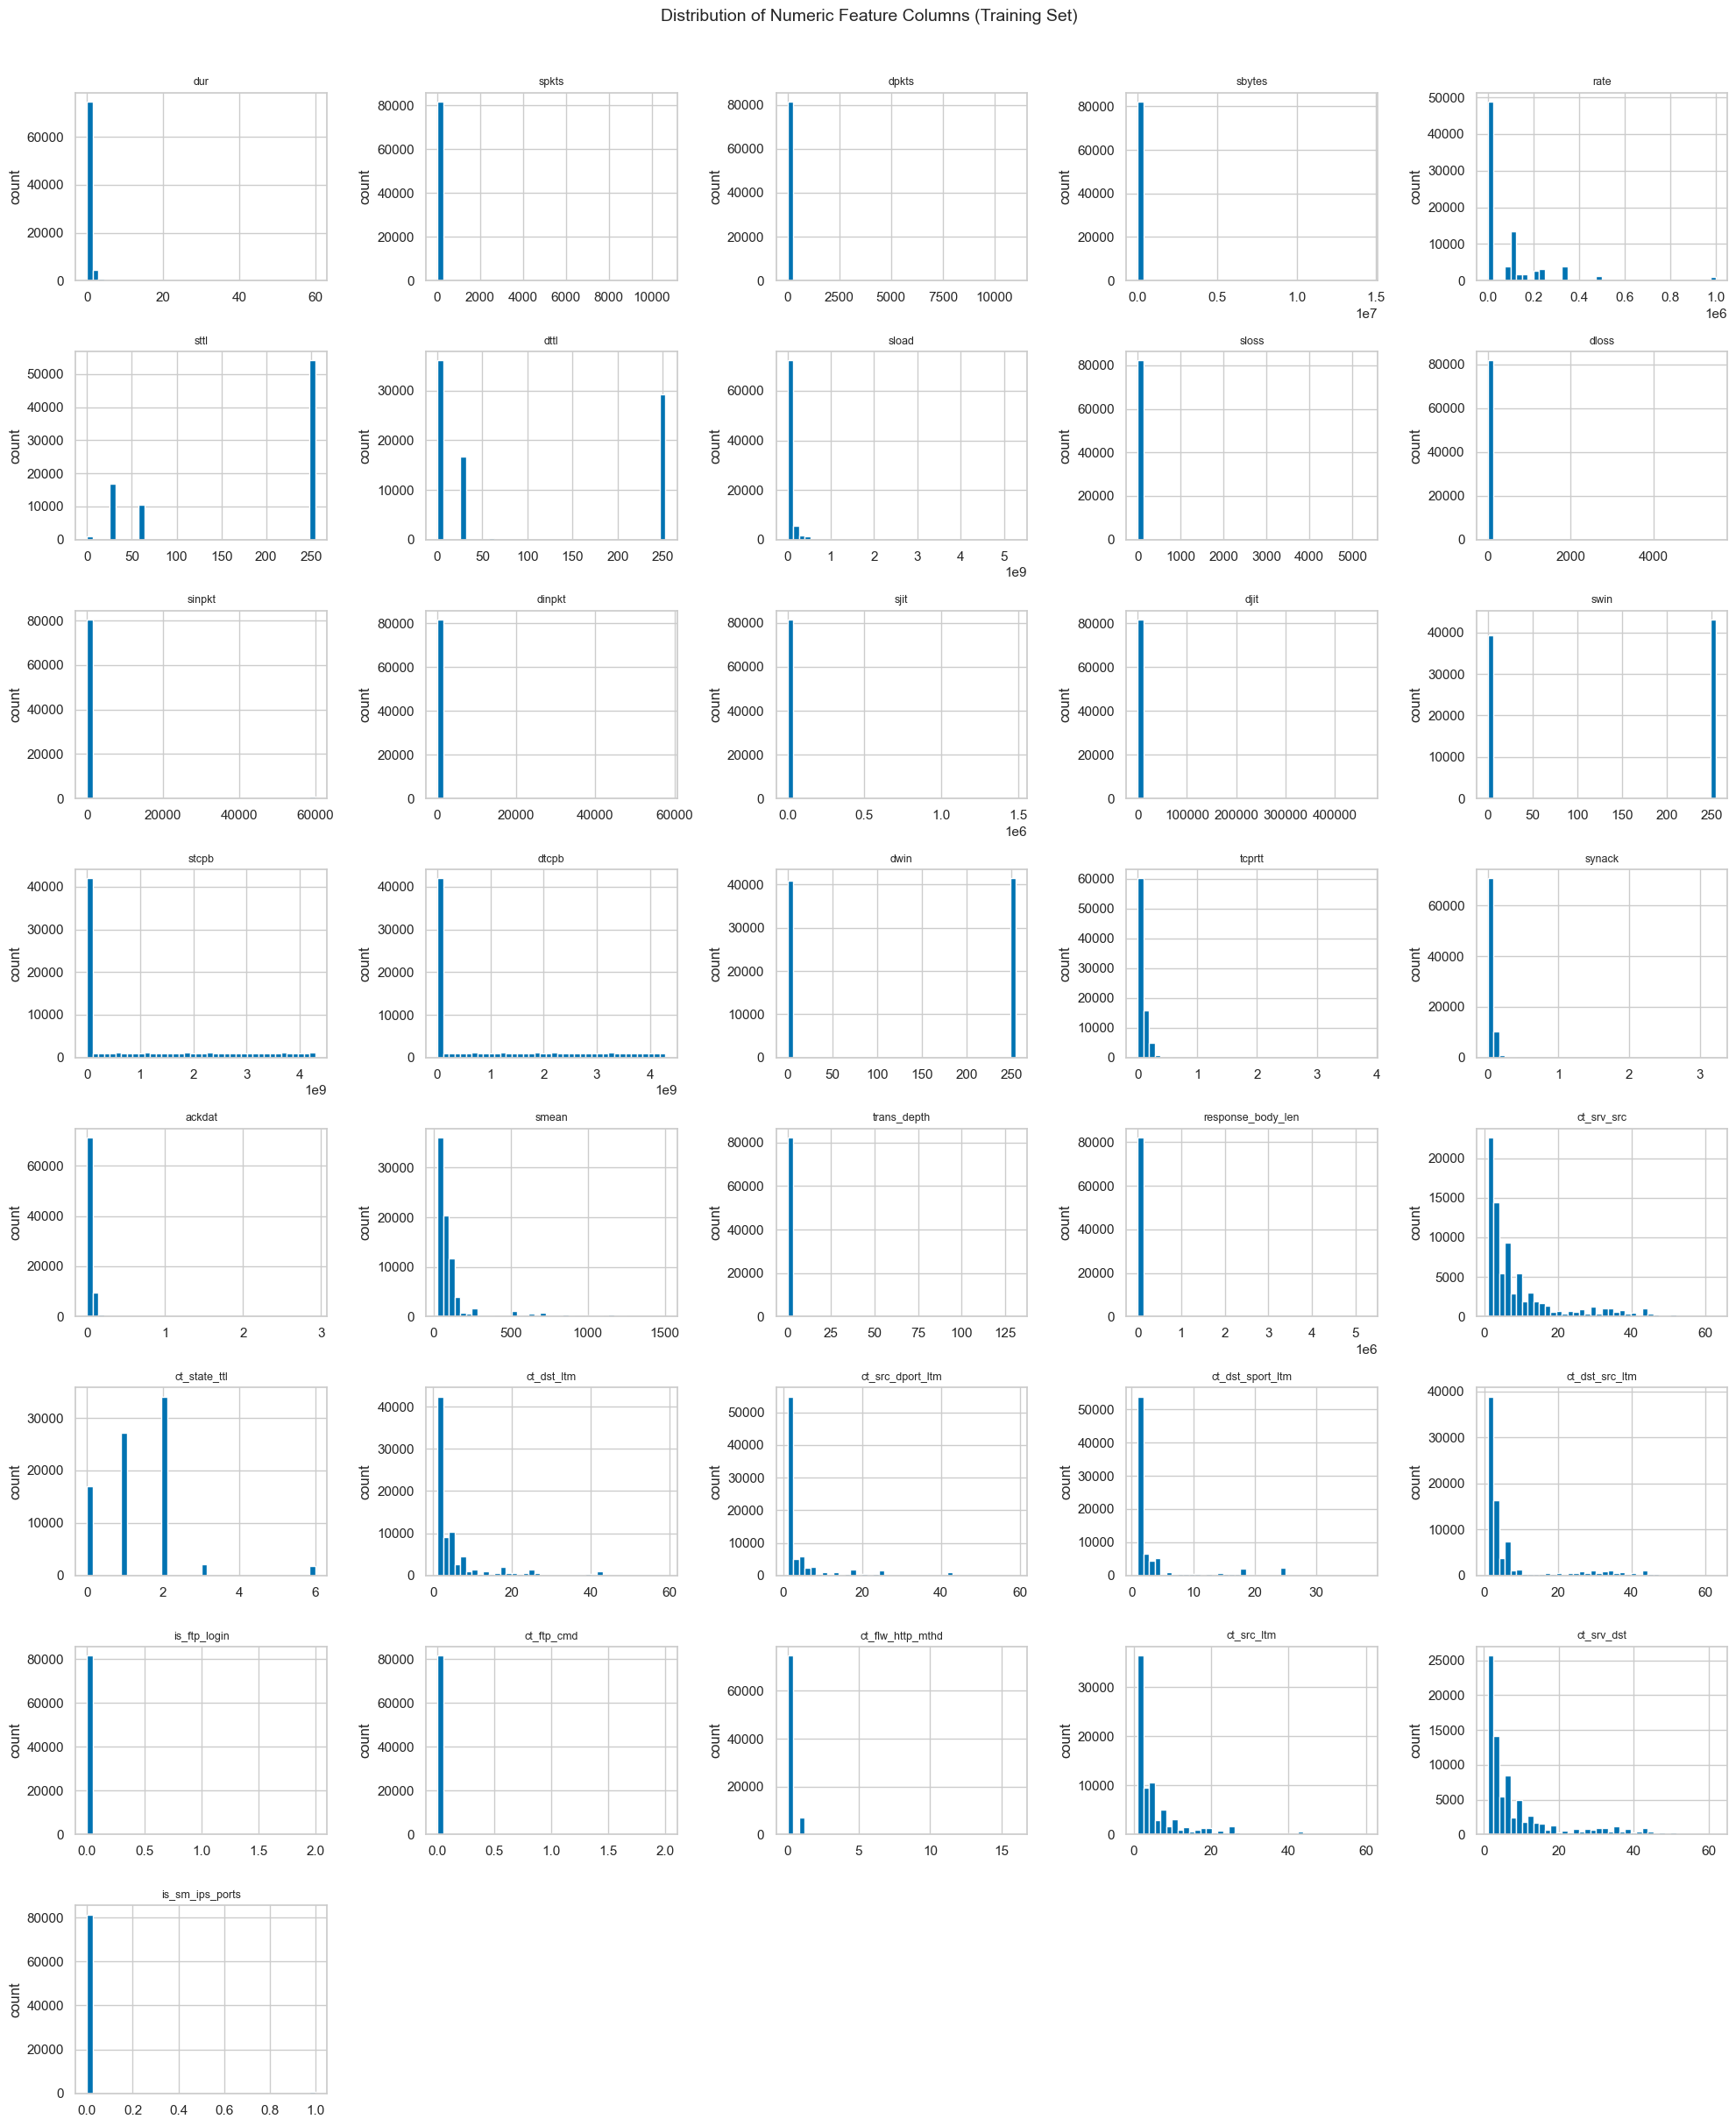

In [6]:
# (i) Distribution plots for numeric features (excluding target/leak columns, shown separately)
exclude_from_grid = {"id", "dbytes", "dmean", "dload"}
numeric_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns
                if c not in exclude_from_grid and c != "label"]

n_cols = 5
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(train_df[col], bins=40, color=sns.color_palette("colorblind")[0])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("count")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Distribution of Numeric Feature Columns (Training Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("reg_eda_feature_distributions.png", bbox_inches="tight")
plt.show()


**Observation (A2-i):** As with the classification-track EDA, most byte/rate/timing features are heavily right-skewed with long tails, and several indicator-style columns (`is_ftp_login`, `is_sm_ips_ports`, `trans_depth`) are sparse near-constants. This motivates log-transforming/IQR-capping the skewed predictors as well, not just the target.


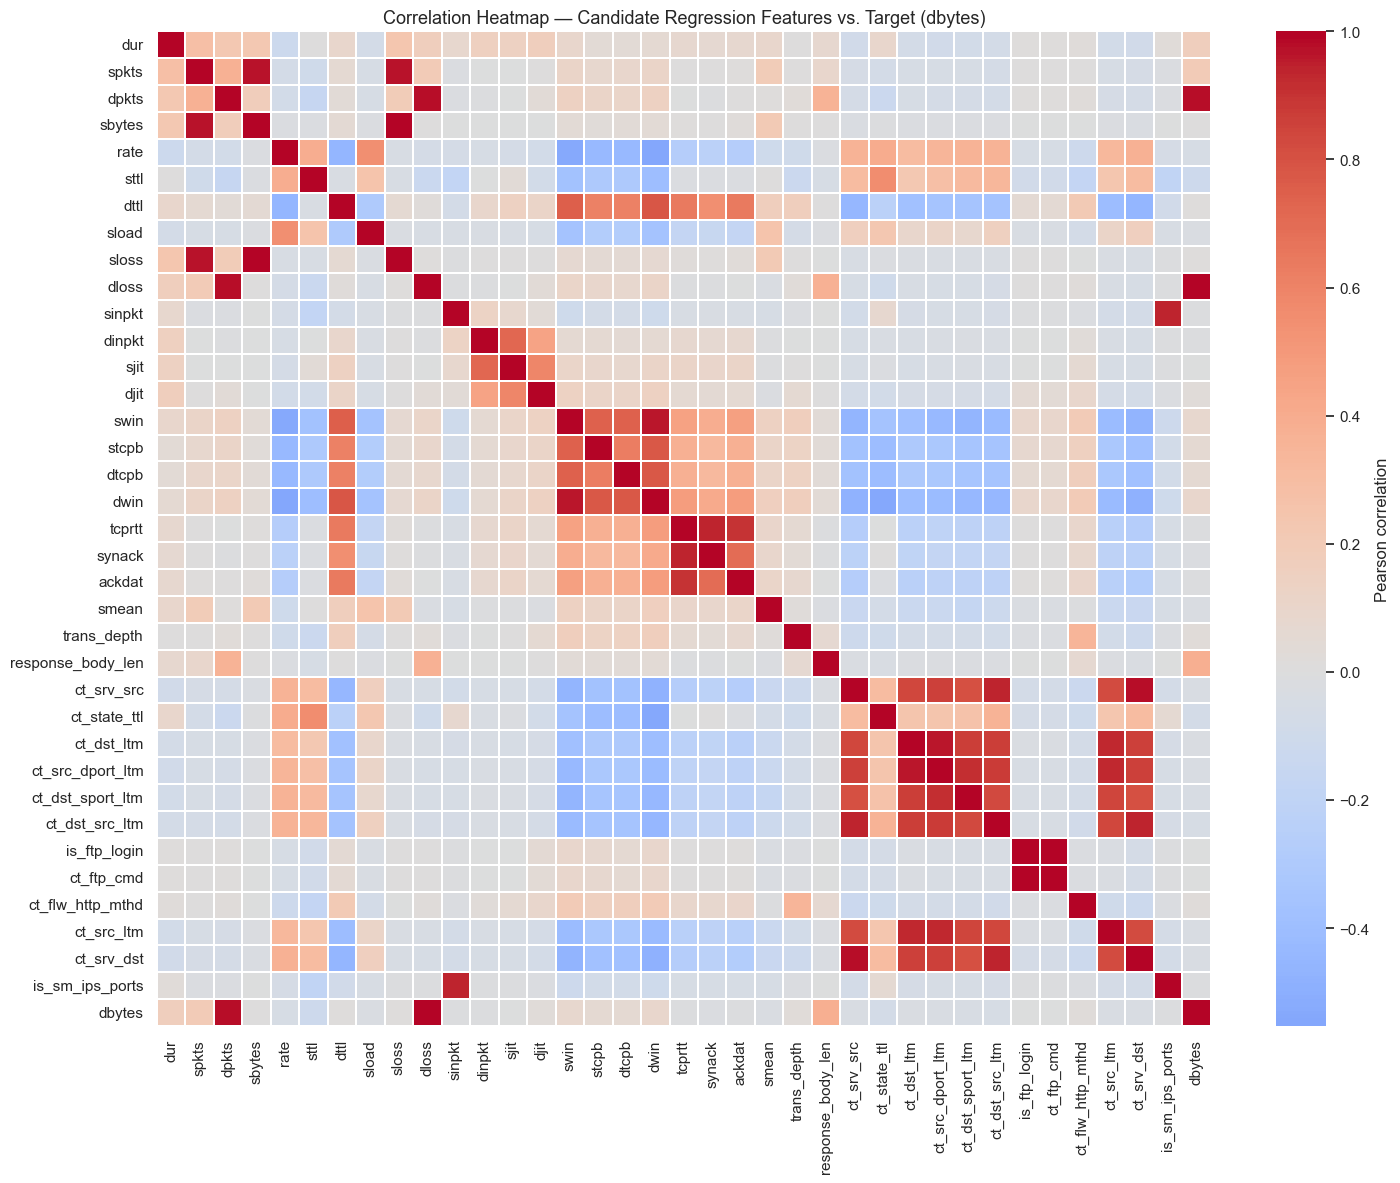

Top 10 features most correlated with dbytes:
dloss                0.997109
dpkts                0.976419
response_body_len    0.382727
spkts                0.198324
dur                  0.172492
sttl                 0.114537
dwin                 0.086472
swin                 0.083015
ct_state_ttl         0.073023
stcpb                0.064456
Name: dbytes, dtype: float64


In [7]:
# (ii) Correlation heatmap (feature set that will actually be used, i.e. leakage columns removed)
corr_cols = [c for c in numeric_cols] + ["dbytes"]
corr = train_df[corr_cols].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation Heatmap — Candidate Regression Features vs. Target (dbytes)", fontsize=13)
plt.tight_layout()
plt.savefig("reg_eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Top 10 features most correlated with dbytes:")
print(corr["dbytes"].drop("dbytes").abs().sort_values(ascending=False).head(10))


**Observation (A2-ii):** With `dmean` and `dload` already removed, the strongest remaining correlate of `dbytes` is `dpkts` (destination packet count, ≈0.98) — expected and legitimate, since more packets generally carry more bytes, but it is not an exact formula. Several `ct_*` connection-history features are mutually correlated with each other (same finding as the classification EDA) — useful to know for regularised linear models (Ridge/Lasso) which will need to handle this multicollinearity.


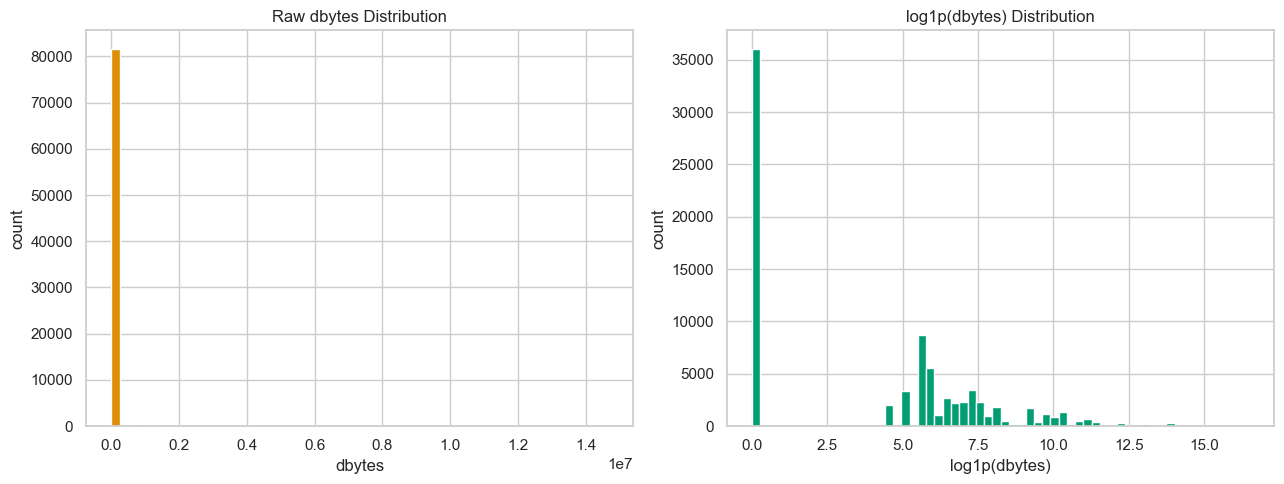

In [8]:
# (iii) Target distribution: raw vs. log1p
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(train_df["dbytes"], bins=60, color=sns.color_palette("colorblind")[1])
axes[0].set_title("Raw dbytes Distribution")
axes[0].set_xlabel("dbytes")
axes[0].set_ylabel("count")

axes[1].hist(np.log1p(train_df["dbytes"]), bins=60, color=sns.color_palette("colorblind")[2])
axes[1].set_title("log1p(dbytes) Distribution")
axes[1].set_xlabel("log1p(dbytes)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig("reg_eda_target_distribution.png", bbox_inches="tight")
plt.show()


**Observation (A2-iii):** The raw target is dominated by a huge spike near zero with a long thin tail out to ~1.47e7 bytes, which would make raw-scale regression dominated by a handful of extreme flows. The `log1p` version is much closer to a workable, roughly multi-modal distribution (a large "no/low response" mode plus a broader mode of substantive responses), confirming `log1p(dbytes)` as the right training target.


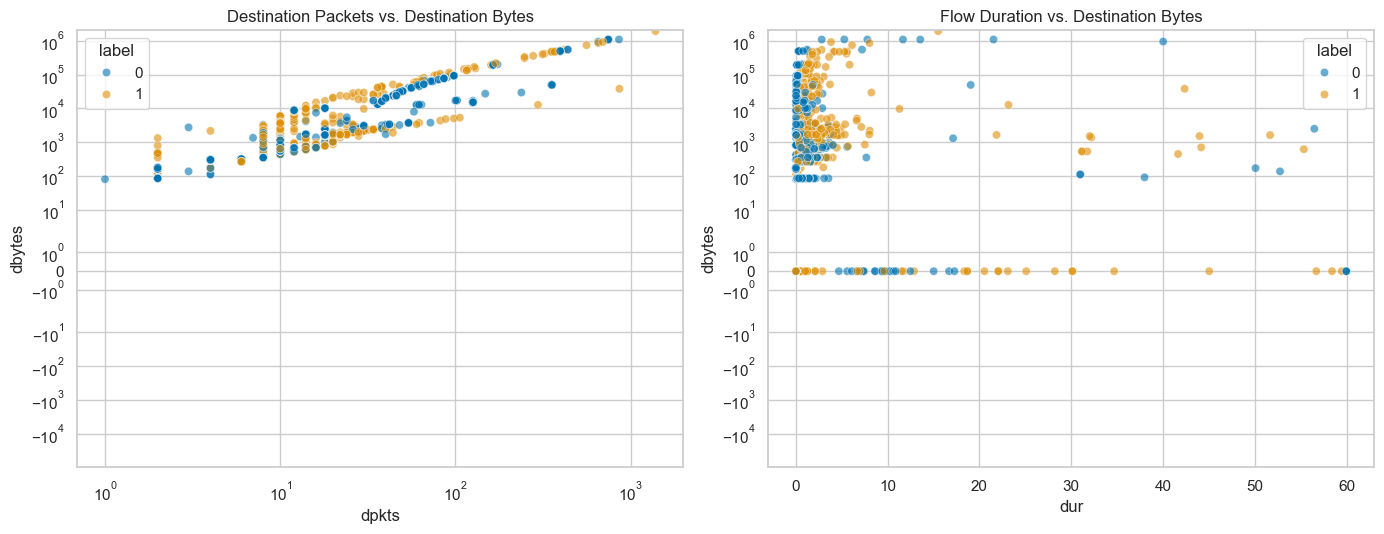

In [9]:
# (iv) Scatter plots: feature vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sample = train_df.sample(4000, random_state=RANDOM_STATE)

sns.scatterplot(data=sample, x="dpkts", y="dbytes", hue="label",
                 palette="colorblind", alpha=0.6, ax=axes[0])
axes[0].set_xscale("log"); axes[0].set_yscale("symlog")
axes[0].set_title("Destination Packets vs. Destination Bytes")

sns.scatterplot(data=sample, x="dur", y="dbytes", hue="label",
                 palette="colorblind", alpha=0.6, ax=axes[1])
axes[1].set_yscale("symlog")
axes[1].set_title("Flow Duration vs. Destination Bytes")

plt.tight_layout()
plt.savefig("reg_eda_scatter_feature_target.png", bbox_inches="tight")
plt.show()


**Observation (A2-iv):** `dpkts` shows a clear, roughly monotonic (though noisy) positive relationship with `dbytes`, as expected — this will likely be one of the most useful predictors. `dur` vs. `dbytes` is much noisier: very short and very long flows can both carry a wide range of response sizes, suggesting duration alone is a weak predictor and will need to be combined with other features (motivating the feature engineering in B3).


## Section B — Preprocessing & Feature Engineering

### B1. Data Cleaning


In [10]:
# --- (1) Missing-value marker in `service` ---
for df_ in (train_df, test_df):
    df_["service"] = df_["service"].replace("-", "no_service")

# --- (2) Duplicate rows ---
dup_train = train_df.duplicated().sum()
dup_test = test_df.duplicated().sum()
print(f"Duplicate rows -> train: {dup_train}, test: {dup_test}")
train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)
print("Shapes after de-duplication:", train_df.shape, test_df.shape)


Duplicate rows -> train: 0, test: 0


Shapes after de-duplication: (82332, 45) (175341, 45)


In [11]:
# --- (3) Drop leakage / out-of-scope columns identified in the intro table ---
# dmean, dload : algebraic leakage of the target (dbytes)
# attack_cat, label : Classification-track targets, deliberately excluded here
# id : row identifier, not a feature
leak_and_scope_cols = ["dmean", "dload", "attack_cat", "label", "id"]
train_df = train_df.drop(columns=leak_and_scope_cols)
test_df = test_df.drop(columns=leak_and_scope_cols)
print("Dropped columns:", leak_and_scope_cols)
print("Remaining shape -> train:", train_df.shape, " test:", test_df.shape)


Dropped columns: ['dmean', 'dload', 'attack_cat', 'label', 'id']
Remaining shape -> train: (82332, 40)  test: (175341, 40)


In [12]:
# --- (4) Outlier treatment: DEFERRED until AFTER the train/validation split ---
# IQR bounds must be computed on the TRAINING split only. Computing them here on
# the full training file would let the validation-fold rows influence the caps
# (mild leakage). We therefore only list the skewed PREDICTOR columns to cap;
# the capping itself is applied in Section B2 right after the split.
# NOTE: we never cap the target `dbytes` itself -- its skew is handled by the
# log1p transform, and capping the target would distort what we're predicting.
skewed_predictor_cols = ["dur", "sbytes", "rate", "sload", "sloss", "dloss",
                          "sinpkt", "dinpkt", "sjit", "djit"]
print("Predictor columns flagged for capping (applied after the split):")
print(skewed_predictor_cols)


Predictor columns flagged for capping (applied after the split):
['dur', 'sbytes', 'rate', 'sload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit']


**Observation (B1):** No exact duplicate rows were found. `dmean`, `dload` (algebraic leaks of the target), `attack_cat`/`label` (out-of-scope classification targets), and `id` (identifier) were dropped from the feature set. Outlier capping on the skewed **predictor** columns is **deferred to after the train/validation split** (Section B2) so the IQR bounds come from the training fold only; the target `dbytes` is never capped (its skew is handled via `log1p`).


### B2. Encoding, Splitting, Outlier Capping & Scaling

Leakage-safe order of operations:

1. **Encode** categoricals (`proto` rare-grouped, then one-hot), dummy columns fixed on the **training file only**; test aligned to those columns.
2. **Split** a train/validation set (80/20) out of the training file, stratified on quantile-binned `log1p(dbytes)`; the provided test file stays as the untouched final hold-out.
3. **Cap outliers** on the skewed predictor columns using IQR bounds from **`X_train` only**, applied (transform-only) to validation and test.
4. **Engineer features** (Section B3) from the *raw, unscaled* values.
5. **Scale** all continuous features (including engineered ones) with a `StandardScaler` **fit on `X_train` only**.


In [13]:
# --- Categorical encoding ---
proto_freq = train_df["proto"].value_counts(normalize=True)
common_protos = proto_freq[proto_freq >= 0.01].index.tolist()
for df_ in (train_df, test_df):
    df_["proto"] = df_["proto"].where(df_["proto"].isin(common_protos), "other")

categorical_cols = ["proto", "service", "state"]
print({c: train_df[c].nunique() for c in categorical_cols})


{'proto': 5, 'service': 13, 'state': 7}


In [14]:
TARGET_COL = "dbytes"

y_full = train_df[TARGET_COL].copy()
y_full_log = np.log1p(y_full)                 # actual training target
y_test_full = test_df[TARGET_COL].copy()
y_test_full_log = np.log1p(y_test_full)

X_full = train_df.drop(columns=[TARGET_COL])
X_test_full = test_df.drop(columns=[TARGET_COL])

X_full_enc = pd.get_dummies(X_full, columns=categorical_cols, drop_first=False)
X_test_enc = pd.get_dummies(X_test_full, columns=categorical_cols, drop_first=False)
X_test_enc = X_test_enc.reindex(columns=X_full_enc.columns, fill_value=0)   # align to train columns

print("Encoded feature matrix shape (train):", X_full_enc.shape)
print("Encoded feature matrix shape (test): ", X_test_enc.shape)


Encoded feature matrix shape (train): (82332, 61)
Encoded feature matrix shape (test):  (175341, 61)


In [15]:
# --- Train/validation split (80/20) ---
# `train_test_split`'s `stratify` argument requires discrete classes; since our
# target is continuous, we approximate stratification by binning log(dbytes)
# into quantile buckets purely for the split, so both splits see a similar
# spread of "small/medium/large response" flows.
target_bins = pd.qcut(y_full_log, q=10, labels=False, duplicates="drop")

X_train, X_val, y_train_log, y_val_log, y_train, y_val = train_test_split(
    X_full_enc, y_full_log, y_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

print("Train:", X_train.shape, " Val:", X_val.shape)


Train: (65865, 61)  Val: (16467, 61)


In [16]:
# --- Step 3: Outlier capping — bounds from X_train ONLY ---
cap_cols = [c for c in skewed_predictor_cols if c in X_train.columns]

outlier_bounds = {}
for col in cap_cols:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

for col, (lower, upper) in outlier_bounds.items():
    X_train[col]   = X_train[col].clip(lower, upper)
    X_val[col]     = X_val[col].clip(lower, upper)
    X_test_enc[col] = X_test_enc[col].clip(lower, upper)

print(f"Capped {len(cap_cols)} predictor columns using IQR bounds from X_train only.")


Capped 10 predictor columns using IQR bounds from X_train only.


In [17]:
# --- Step 4: Feature engineering on RAW (unscaled) values ---
# Built BEFORE scaling so log/sum/flag features use real values and stay
# meaningful; they are scaled together with everything else in Step 5.
def engineer_features(df):
    df = df.copy()

    # 1. log1p(dur): duration is heavily right-skewed; a log version gives
    #    linear models a far more usable, less outlier-dominated predictor.
    df["log_dur"] = np.log1p(df["dur"].clip(lower=0))

    # 2. src_activity_score: consolidates three correlated source-host
    #    connection counters into one activity signal. A very active source
    #    (busy server, or scanning/flooding host) plausibly exchanges data
    #    differently than a quiet host.
    df["src_activity_score"] = (df["ct_srv_src"] + df["ct_src_ltm"] +
                                 df["ct_src_dport_ltm"])

    # 3. is_tcp: explicit TCP flag. TCP's handshake/ACK mechanics structurally
    #    change how response bytes are returned vs. connectionless UDP/other.
    df["is_tcp"] = df["proto_tcp"] if "proto_tcp" in df.columns else 0

    return df

X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)
X_test_enc = engineer_features(X_test_enc)

print("Engineered (on raw values):", ["log_dur", "src_activity_score", "is_tcp"])
print("Shapes -> train:", X_train.shape, " val:", X_val.shape, " test:", X_test_enc.shape)


Engineered (on raw values): ['log_dur', 'src_activity_score', 'is_tcp']
Shapes -> train: (65865, 64)  val: (16467, 64)  test: (175341, 64)


In [18]:
# --- Step 5: Scaling — StandardScaler fit on X_train ONLY (engineered cols included) ---
numeric_feature_cols = [c for c in X_train.columns
                         if X_train[c].dtype != "bool" and X_train[c].nunique() > 2]

scaler = StandardScaler()
scaler.fit(X_train[numeric_feature_cols])          # fit on train ONLY

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[numeric_feature_cols] = scaler.transform(X_train[numeric_feature_cols])
X_val_scaled[numeric_feature_cols]   = scaler.transform(X_val[numeric_feature_cols])
X_test_scaled[numeric_feature_cols]  = scaler.transform(X_test_enc[numeric_feature_cols])

print(f"Scaled {len(numeric_feature_cols)} continuous columns (incl. the 3 engineered ones).")
print("Scaler fit on X_train ONLY; validation/test transform-only.")


Scaled 37 continuous columns (incl. the 3 engineered ones).
Scaler fit on X_train ONLY; validation/test transform-only.


**Observation (B2):** Rare `proto` categories were grouped into `"other"` for generalisation. The pipeline now runs **encode → split → cap → engineer → scale**: the split precedes every fitted transform, IQR caps and the `StandardScaler` are fit on `X_train` only, and the engineered features are built from raw values then scaled alongside the rest. The split is stratified on quantile buckets of `log1p(dbytes)` so both folds see a comparable spread of small/large-response flows.


### B3. Feature Engineering — Notes & Justification

Created in **Step 4 above** (before scaling, on raw values). This section documents and inspects them.

| Feature | Definition | Why it may help |
|---|---|---|
| `log_dur` | `log1p(dur)` | Duration is heavily right-skewed; the log form is far more usable for linear models. |
| `src_activity_score` | `ct_srv_src + ct_src_ltm + ct_src_dport_ltm` | One consolidated source-host activity signal instead of three correlated counters. |
| `is_tcp` | 1 if protocol is TCP | TCP's handshake/ACK mechanics change how response bytes return vs. UDP/other. |


In [19]:
# Inspect engineered features on the RAW (pre-scaling) training split.
X_train[["log_dur", "src_activity_score", "is_tcp"]].describe()


,log_dur,src_activity_score
count,65865.000000,65865.000000
mean,0.274384,20.938875
std,0.355075,26.728624
min,0.000000,3.000000
25%,0.000008,5.000000
50%,0.014531,10.000000
75%,0.542469,22.000000
max,1.029837,178.000000


**Observation (B3):** Because `log_dur` is now computed on the *raw* `dur` (not the scaled z-score), it spans a genuine positive range instead of collapsing most rows to zero, so it carries real information. `src_activity_score` and `is_tcp` are likewise built from raw values, then all three are scaled with the train-only scaler in Step 5 — no leakage, and every feature ends up on a comparable scale for the distance/gradient-based models (SVR, KNN, linear family).


## Save Preprocessed Data for the Regression Notebook

We persist the cleaned, encoded, scaled, feature-engineered splits — including both the log-transformed training target and the original-scale `dbytes` (for reporting RMSE/MAE back in real byte units) — so the modelling notebook (`regression.ipynb`) can load them directly.


In [20]:
import os
os.makedirs("processed_data", exist_ok=True)

X_train_scaled.assign(dbytes_log=y_train_log.values, dbytes=y_train.values)\
    .to_csv("processed_data/reg_train_processed.csv", index=False)

X_val_scaled.assign(dbytes_log=y_val_log.values, dbytes=y_val.values)\
    .to_csv("processed_data/reg_val_processed.csv", index=False)

X_test_scaled.assign(dbytes_log=y_test_full_log.values, dbytes=y_test_full.values)\
    .to_csv("processed_data/reg_test_processed.csv", index=False)

print("Saved: processed_data/reg_train_processed.csv, reg_val_processed.csv, reg_test_processed.csv")
print("Train models against the 'dbytes_log' column; convert predictions back with "
      "np.expm1(pred) and compare against the 'dbytes' column for real-unit RMSE/MAE.")


Saved: processed_data/reg_train_processed.csv, reg_val_processed.csv, reg_test_processed.csv
Train models against the 'dbytes_log' column; convert predictions back with np.expm1(pred) and compare against the 'dbytes' column for real-unit RMSE/MAE.


## Summary

| Step | What was done |
|---|---|
| — | Chose `dbytes` (destination bytes) as the continuous regression target, verified via correlation analysis that `dmean`/`dload` are algebraic leaks of it and dropped them; excluded `attack_cat`/`label` to keep the Regression and Classification tracks cleanly separated |
| A1 | Loaded train/test files, audited shape/dtypes/missing values, and the target's heavy skew (motivating a log1p transform) |
| A2 | Plotted feature distributions, a correlation heatmap (post leakage-removal), raw-vs-log target distributions, and 2 feature-vs-target scatter plots, each with a written interpretation |
| B1 | Recoded the `service` placeholder, dropped duplicates/leakage/out-of-scope columns, IQR-capped outliers in skewed **predictor** columns only (bounds from train), left the target untouched |
| B2 | Grouped rare `proto` values, one-hot encoded categoricals (fit on train), created an 80/20 train/validation split stratified on quantile-binned target, scaled numeric features with a scaler fit on train only |
| B3 | Engineered 3 new leakage-free features (`log_dur`, `src_activity_score`, `is_tcp`) with justifications |
| — | Saved final train/validation/test splits to `processed_data/` (with both `dbytes_log` and original-scale `dbytes`) for the Regression modelling notebook |

**Next step (outside this notebook):** train all 10 required regression algorithms (Linear, Ridge, Lasso, ElasticNet, Polynomial, Decision Tree, Random Forest, Gradient Boosting, SVR, KNN) on `reg_train_processed.csv` against `dbytes_log`, evaluate with R², RMSE, MAE (converting predictions back to byte units with `np.expm1`), run 5-fold CV on the two best models, and produce the residual / predicted-vs-actual / feature-importance plots required by Review 1 Section C.
